In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # se o notebook está dentro de notebooks/
sys.path.insert(0, str(PROJECT_ROOT))
data_path = PROJECT_ROOT.parent.parent / "data"

print(data_path)

c:\Users\Camille\Documents\Artigos\TWR\data


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

# Importando a sua rede de duas cabeças
# Assumindo que a classe ContrastiveClusteringNet está no arquivo contrastive_clustering.py
from src.contrastive_clustering import ContrastiveClusteringNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Rodando em: {device}")

Rodando em: cuda


In [3]:
import os
import torch
from src.datasets import process_traffic_data, TripletTrafficDataset
from torch.utils.data import DataLoader

cache_file = f'{data_path}/processed_features_labels.pt'

# 1. Tenta carregar do cache primeiro (MUITO mais rápido)
if os.path.exists(cache_file):
    print("Carregando features pré-processadas do cache...")
    features, labels = torch.load(cache_file, weights_only=False)
else:
    print("Processando JSONs pela primeira vez...")
    features, labels = process_traffic_data(
        fr'{data_path}/outbrain-unsafe-10k.json', 
        fr'{data_path}/outbrain-bot-10k.json'
    )
    # Salva para a próxima vez
    torch.save((features, labels), cache_file)
    print("Cache salvo com sucesso!")

input_dim = features.shape[1]
print(f"Total de amostras: {features.shape[0]} | Features: {input_dim}")

Carregando features pré-processadas do cache...
Total de amostras: 20000 | Features: 68


In [4]:
import torch
from torch.utils.data import DataLoader

# 1. Importando os módulos recém-criados
from src.data_argumentation import AugmentedTrafficDataset
from src.contrastive_clustering import ContrastiveClusteringNet, InstanceLoss, ClusterLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Treinando na device: {device}")

# 2. Configurando os Dados (assumindo que 'features' já foi extraído via SVD)
# features = matriz numpy com suas 39.950 ou 20.000 amostras (68 dimensões)
dataset = AugmentedTrafficDataset(features, mask_prob=0.15, noise_std=0.05)

# Dataloader otimizado (pin_memory ajuda na transferência rápida para a GPU)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=True, pin_memory=True)

# 3. Inicializando o Modelo e as Funções de Perda
input_dim = features.shape[1]
model = ContrastiveClusteringNet(input_dim=input_dim, num_clusters=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Instanciando as duas perdas do aprendizado contrastivo
loss_instance_fn = InstanceLoss(temperature=0.5).to(device)
loss_cluster_fn = ClusterLoss(temperature=1.0).to(device)

# 4. Loop de Treinamento
epochs = 30
model.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    
    for view_a, view_b in dataloader:
        # Envia as duas visões perturbadas para a GPU/CPU
        view_a, view_b = view_a.to(device), view_b.to(device)
        
        optimizer.zero_grad()
        
        # Passa ambas as visões pelo modelo para extrair representações e clusters
        z_i, p_i = model(view_a)
        z_j, p_j = model(view_b)
        
        # Calcula a Dual Loss
        l_ins = loss_instance_fn(z_i, z_j)
        l_clu = loss_cluster_fn(p_i, p_j)
        
        loss = l_ins + l_clu
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    print(f"Epoch [{epoch+1}/{epochs}] | Loss Média: {epoch_loss/len(dataloader):.4f}")

Treinando na device: cuda
Epoch [1/30] | Loss Média: 6.3550
Epoch [2/30] | Loss Média: 5.4145
Epoch [3/30] | Loss Média: 5.2090
Epoch [4/30] | Loss Média: 5.1567
Epoch [5/30] | Loss Média: 5.1189
Epoch [6/30] | Loss Média: 5.0940
Epoch [7/30] | Loss Média: 5.0769
Epoch [8/30] | Loss Média: 5.0637
Epoch [9/30] | Loss Média: 5.0527
Epoch [10/30] | Loss Média: 5.0441
Epoch [11/30] | Loss Média: 5.0384
Epoch [12/30] | Loss Média: 5.0321
Epoch [13/30] | Loss Média: 5.0285
Epoch [14/30] | Loss Média: 5.0250
Epoch [15/30] | Loss Média: 5.0211
Epoch [16/30] | Loss Média: 5.0169
Epoch [17/30] | Loss Média: 5.0136
Epoch [18/30] | Loss Média: 5.0112
Epoch [19/30] | Loss Média: 5.0073
Epoch [20/30] | Loss Média: 5.0048
Epoch [21/30] | Loss Média: 5.0028
Epoch [22/30] | Loss Média: 5.0009
Epoch [23/30] | Loss Média: 4.9997
Epoch [24/30] | Loss Média: 4.9968
Epoch [25/30] | Loss Média: 4.9976
Epoch [26/30] | Loss Média: 4.9962
Epoch [27/30] | Loss Média: 4.9938
Epoch [28/30] | Loss Média: 4.9923
Epo

Extraindo representações limpas e previsões do modelo...
Calculando t-SNE para visualização (isso pode levar um minuto)...


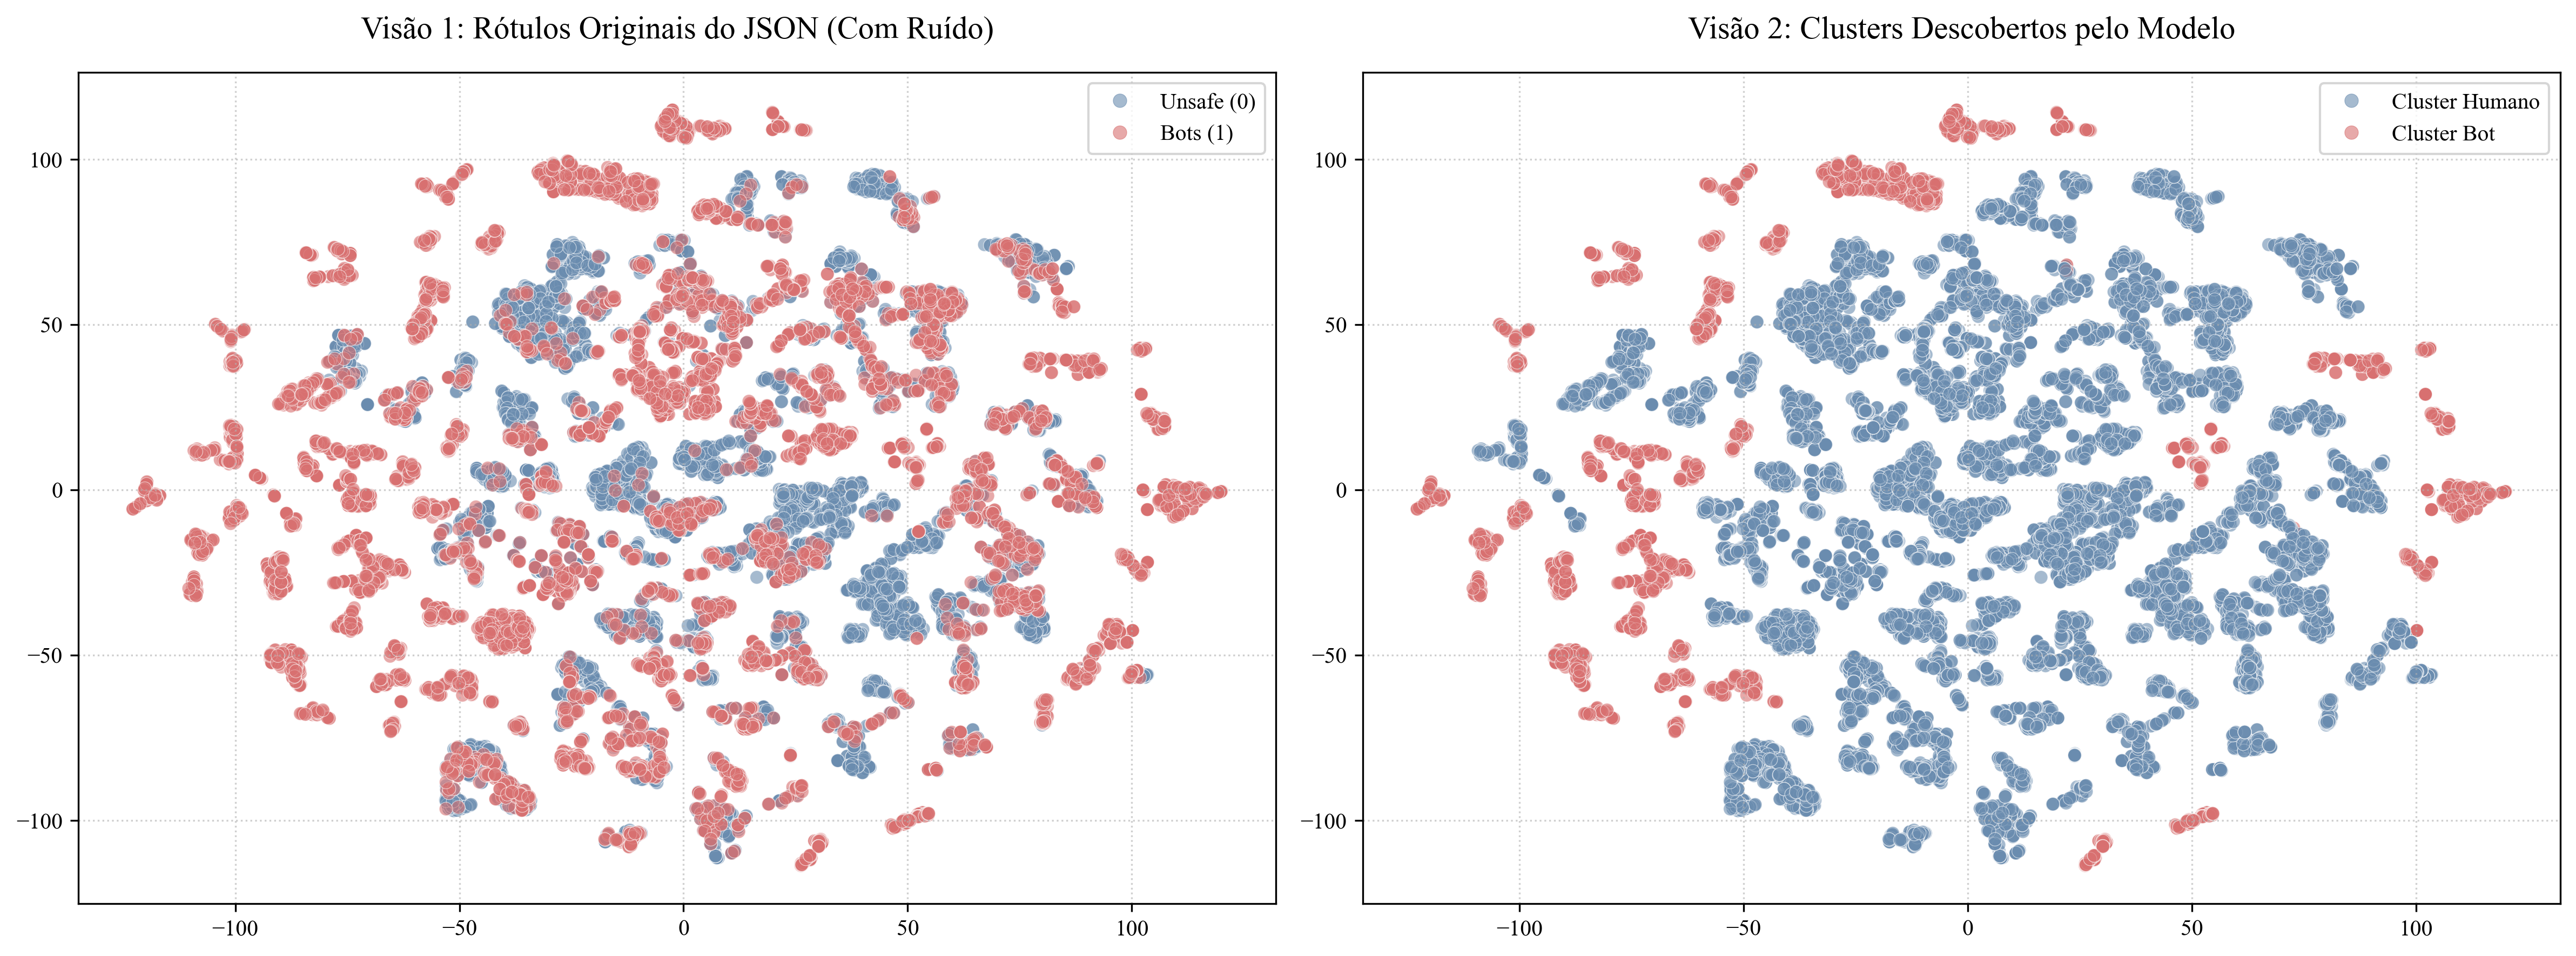


RELATÓRIO DE AUDITORIA E ANOMALIAS
Total de requisições analisadas: 20000
-> Falsos Humanos (Estava 'Unsafe', mas o modelo agrupou como 'Bot'): 0 amostras
-> Falsos Bots (Estava 'Bot', mas o modelo agrupou como 'Unsafe'): 5703 amostras
Taxa de Ruído de Rótulo detectada: 28.52%



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap

# 1. Configuração de Fonte para Artigo (Opcional, mantém o padrão)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

print("Extraindo representações limpas e previsões do modelo...")
model.eval()

# Pegamos as features originais (sem o ruído do Data Augmentation)
clean_features = dataset.features.to(device)

with torch.no_grad():
    # O modelo retorna os embeddings contínuos (z) e as probabilidades de cluster (p)
    z_instance, p_cluster = model(clean_features)
    
    # O cluster final é aquele com maior probabilidade
    predicted_clusters = torch.argmax(p_cluster, dim=1).cpu().numpy()
    embeddings_np = z_instance.cpu().numpy()

# 2. Redução de Dimensionalidade (t-SNE)
print("Calculando t-SNE para visualização (isso pode levar um minuto)...")
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_np)

# 3. Mapeamento de Clusters (Descobrindo quem é quem)
# Cruzamos com os labels originais apenas para nomear os clusters logicamente
# labels = seus rótulos originais do JSON (0 para Unsafe, 1 para Bots)
resultados = pd.DataFrame({
    'Rotulo_Original': labels,
    'Cluster_Modelo': predicted_clusters
})

# Identifica qual cluster concentrou a maioria dos dados "Unsafe" (Humanos)
cluster_humano = resultados[resultados['Rotulo_Original'] == 0]['Cluster_Modelo'].mode()[0]
cluster_bot = 1 - cluster_humano

# 4. Plotagem Dupla (O Antes e o Depois)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
cmap_soft = ListedColormap(['#6A8CAF', '#D87070']) # Azul Suave, Vermelho Suave

# Gráfico 1: A visão baseada nos Rótulos Ruidosos Originais
scatter1 = ax1.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                       c=labels, cmap=cmap_soft, alpha=0.6, edgecolors='white', linewidth=0.3)
ax1.set_title("Visão 1: Rótulos Originais do JSON (Com Ruído)", pad=15, fontsize=14)
ax1.legend(handles=scatter1.legend_elements()[0], labels=['Unsafe (0)', 'Bots (1)'])
ax1.grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: A visão baseada na Descoberta do Modelo
# Mapeamos as cores para bater visualmente (Humano=Azul, Bot=Vermelho)
cores_modelo = np.where(predicted_clusters == cluster_bot, 1, 0)
scatter2 = ax2.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                       c=cores_modelo, cmap=cmap_soft, alpha=0.6, edgecolors='white', linewidth=0.3)
ax2.set_title("Visão 2: Clusters Descobertos pelo Modelo", pad=15, fontsize=14)
ax2.legend(handles=scatter2.legend_elements()[0], labels=['Cluster Humano', 'Cluster Bot'])
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('comparativo_clustering.pdf', format='pdf', bbox_inches='tight')
plt.show()

# 5. O Relatório de Auditoria (Extrator de Anomalias)
falsos_humanos = resultados[(resultados['Rotulo_Original'] == 0) & (resultados['Cluster_Modelo'] == cluster_bot)]
falsos_bots = resultados[(resultados['Rotulo_Original'] == 1) & (resultados['Cluster_Modelo'] == cluster_humano)]

print("\n" + "="*50)
print("RELATÓRIO DE AUDITORIA E ANOMALIAS")
print("="*50)
print(f"Total de requisições analisadas: {len(labels)}")
print(f"-> Falsos Humanos (Estava 'Unsafe', mas o modelo agrupou como 'Bot'): {len(falsos_humanos)} amostras")
print(f"-> Falsos Bots (Estava 'Bot', mas o modelo agrupou como 'Unsafe'): {len(falsos_bots)} amostras")
print(f"Taxa de Ruído de Rótulo detectada: {((len(falsos_humanos) + len(falsos_bots)) / len(labels)) * 100:.2f}%\n")

# Mostrando os índices das piores anomalias (para você investigar manualmente no JSON depois)
if len(falsos_humanos) > 0:
    print("Índices de alguns Falsos Humanos (Investigue estes no JSON):")
    print(list(falsos_humanos.index[:10])) # Mostra os primeiros 10